In [1]:
import matplotlib.pyplot as plt
import pandas as pd

base = pd.read_csv("Tabela_Espectros.csv", decimal=',')
base.drop(["Data", "Code"], axis=1, inplace=True)
base.head()

,Planta,Contagio,350,351,352,353,354,355,356,357,...,2451,2452,2453,2454,2455,2456,2457,2458,2459,2460
0,Cotton,Control,0.098600,0.099700,0.098200,0.097900,0.097400,0.096600,0.099100,0.098000,...,0.0476,0.042100,0.032900,0.02060,0.03280,0.0390,0.01720,0.02240,0.0652,0.0780
1,Cotton,Control,0.097000,0.097700,0.099600,0.098205,0.096200,0.095500,0.094528,0.095400,...,-0.0262,-0.027705,-0.035500,-0.03430,-0.00506,0.0040,0.00866,-0.00063,-0.0471,-0.0443
2,Cotton,Control,0.088400,0.091600,0.091000,0.090200,0.088900,0.087200,0.087400,0.087900,...,0.0175,0.016300,0.008860,0.00832,0.01730,0.0255,0.04280,0.04330,0.0359,0.0310
3,Cotton,Control,0.083700,0.085400,0.084521,0.083800,0.083400,0.083348,0.083700,0.083500,...,0.0648,0.074900,0.074424,0.07440,0.09750,0.0867,0.03020,0.01950,0.0184,0.0167
4,Cotton,Control,0.113774,0.114093,0.112957,0.111864,0.111473,0.111628,0.111030,0.109726,...,0.0421,0.045400,0.093900,0.09860,0.04840,0.0491,0.07890,0.07620,0.0763,0.0828


In [2]:
base_soja = base[base["Planta"] == "Soy"]
base_soja.head()

,Planta,Contagio,350,351,352,353,354,355,356,357,...,2451,2452,2453,2454,2455,2456,2457,2458,2459,2460
489,Soy,Control,0.036400,0.033300,0.034700,0.036800,0.037491,0.0362,0.034300,0.036000,...,0.105342,0.103082,0.075099,0.069600,0.084100,0.086200,0.105369,0.093100,0.034018,0.02110
490,Soy,Control,0.019800,0.022200,0.018400,0.019600,0.021100,0.0196,0.019600,0.019400,...,-0.001700,-0.005950,0.015400,0.018700,0.037700,0.041300,0.022200,0.011300,-0.015200,-0.00600
491,Soy,Control,0.018054,0.014668,0.015500,0.016200,0.017000,0.0181,0.018726,0.017165,...,-0.017537,-0.031900,-0.048200,-0.041200,-0.025200,-0.013500,0.033000,0.042000,0.005510,0.00715
492,Soy,Control,0.020100,0.017300,0.019241,0.022825,0.021700,0.0161,0.019700,0.020300,...,0.027700,0.038100,0.054800,0.052800,0.106231,0.102623,-0.006900,-0.014700,0.051600,0.05340
493,Soy,Control,0.013400,0.013700,0.013500,0.017700,0.018400,0.0137,0.017900,0.017240,...,-0.023100,-0.026100,0.055400,0.055562,0.023700,0.015100,-0.041538,-0.056672,-0.013100,-0.00362


In [3]:
print(base_soja["Contagio"].unique())

['Control' 'Caterpillar' 'Bug']


In [4]:
base_soja_Y = base_soja["Contagio"]
base_soja_X = base_soja.drop(["Planta", "Contagio"], axis = 1, inplace=False)


In [5]:
base_soja_X.head()

,350,351,352,353,354,355,356,357,358,359,...,2451,2452,2453,2454,2455,2456,2457,2458,2459,2460
489,0.036400,0.033300,0.034700,0.036800,0.037491,0.0362,0.034300,0.036000,0.037328,0.034600,...,0.105342,0.103082,0.075099,0.069600,0.084100,0.086200,0.105369,0.093100,0.034018,0.02110
490,0.019800,0.022200,0.018400,0.019600,0.021100,0.0196,0.019600,0.019400,0.019600,0.020500,...,-0.001700,-0.005950,0.015400,0.018700,0.037700,0.041300,0.022200,0.011300,-0.015200,-0.00600
491,0.018054,0.014668,0.015500,0.016200,0.017000,0.0181,0.018726,0.017165,0.015993,0.017347,...,-0.017537,-0.031900,-0.048200,-0.041200,-0.025200,-0.013500,0.033000,0.042000,0.005510,0.00715
492,0.020100,0.017300,0.019241,0.022825,0.021700,0.0161,0.019700,0.020300,0.019600,0.021100,...,0.027700,0.038100,0.054800,0.052800,0.106231,0.102623,-0.006900,-0.014700,0.051600,0.05340
493,0.013400,0.013700,0.013500,0.017700,0.018400,0.0137,0.017900,0.017240,0.015000,0.016500,...,-0.023100,-0.026100,0.055400,0.055562,0.023700,0.015100,-0.041538,-0.056672,-0.013100,-0.00362


In [6]:
base_soja_Y.head()

489    Control
490    Control
491    Control
492    Control
493    Control
Name: Contagio, dtype: object

In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

mlp = MLPClassifier()
knn = KNeighborsClassifier()
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

In [8]:
from sklearn.model_selection import cross_val_predict

mlp_predict = cross_val_predict(mlp, base_soja_X, base_soja_Y, cv=5)

In [9]:
knn_predict = cross_val_predict(knn, base_soja_X, base_soja_Y, cv=5)

In [10]:
rf_predict = cross_val_predict(rf, base_soja_X, base_soja_Y, cv=5)

In [11]:
dt_predict = cross_val_predict(dt, base_soja_X, base_soja_Y, cv=5)

In [13]:
from sklearn.metrics import accuracy_score

mlp_score = accuracy_score(base_soja_Y, mlp_predict)
knn_score = accuracy_score(base_soja_Y, knn_predict)
rf_score = accuracy_score(base_soja_Y, rf_predict)
dt_score = accuracy_score(base_soja_Y, dt_predict)

print("Acurácia Média MLP: ", mlp_score)
print("Acurácia Média KNN: ", knn_score)
print("Acurácia Média RF: ", rf_score)
print("Acurácia Média DT: ", dt_score)

Acurácia Média MLP:  0.4886561954624782
Acurácia Média KNN:  0.3944153577661431
Acurácia Média RF:  0.45782431646305993
Acurácia Média DT:  0.39208842350203604


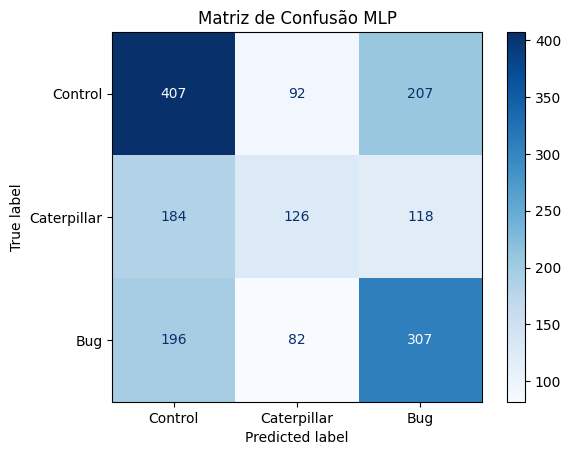

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

unique_classes = base_soja_Y.unique()

mlp_confusion_matrix = confusion_matrix(base_soja_Y, mlp_predict)

mlp_disp = ConfusionMatrixDisplay(confusion_matrix=mlp_confusion_matrix, display_labels=unique_classes)
mlp_disp.plot(cmap=plt.cm.Blues)

# Exibir o gráfico na tela
plt.title("Matriz de Confusão MLP")
plt.show()

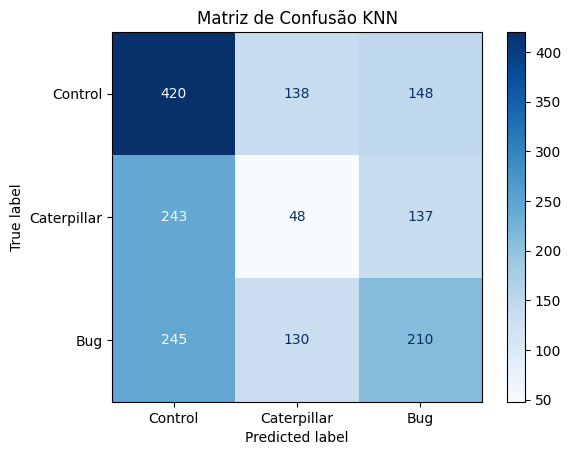

In [19]:
knn_confusion_matrix = confusion_matrix(base_soja_Y, knn_predict)

knn_disp = ConfusionMatrixDisplay(confusion_matrix=knn_confusion_matrix, display_labels=unique_classes)
knn_disp.plot(cmap=plt.cm.Blues)

# Exibir o gráfico na tela
plt.title("Matriz de Confusão KNN")
plt.show()

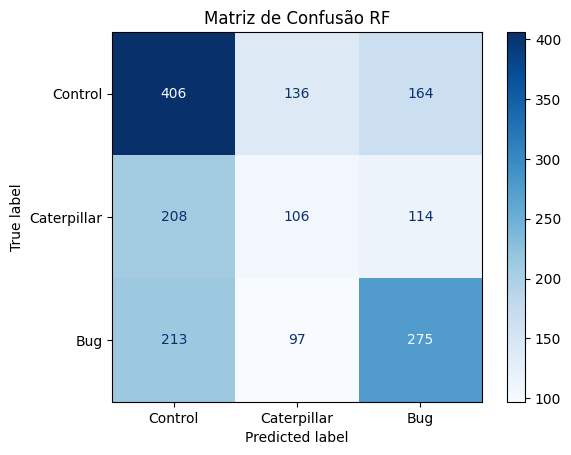

In [21]:
rf_confusion_matrix = confusion_matrix(base_soja_Y, rf_predict)

rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix, display_labels=unique_classes)
rf_disp.plot(cmap=plt.cm.Blues)

# Exibir o gráfico na tela
plt.title("Matriz de Confusão RF")
plt.show()

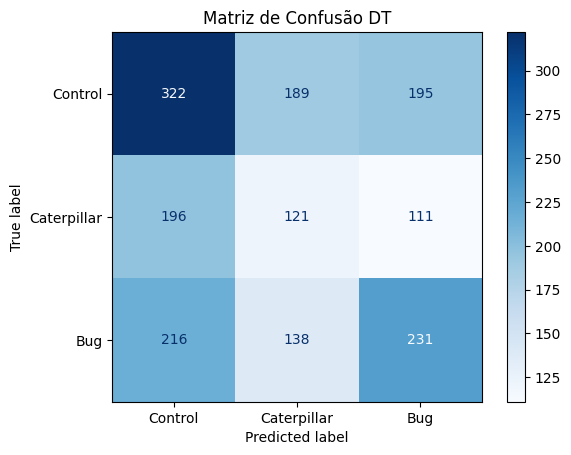

In [22]:
dt_confusion_matrix = confusion_matrix(base_soja_Y, dt_predict)

dt_disp = ConfusionMatrixDisplay(confusion_matrix=dt_confusion_matrix, display_labels=unique_classes)
dt_disp.plot(cmap=plt.cm.Blues)

# Exibir o gráfico na tela
plt.title("Matriz de Confusão DT")
plt.show()